In [138]:
import Symbolics as Sym
using Gen
using Combinatorics
using DataFrames
using Plots

import probability: prob, event_occurency, datas

# The Nature of Randomness

## Lecture 2

The basic goal of probability is to describe what it is that we should expect
from randomness, and so in this lecture we’re going to try to undertake
an understanding in some detail of the nature of random processes.

In [2]:
Sym.@variables p E J K Q A; #use sets for events and prob space omega

### Law of Large Numbers

Find pattern in random event, the more we roll a dice the more we get to the probability to get a 3.

In [3]:
1/6

0.16666666666666666

Trowing the die 6 time we might not get any 3.

In [4]:
event_occurency(3, rand(datas.Dice, 6))

1

Even if there is a $\dfrac{1}{6}$ chance to get it.

In [5]:
prob(event_occurency(3, rand(datas.Dice, 6)), 6)

0.0

But if we try 60.000 times we might ge it x times!

In [6]:
event_occurency(3, rand(datas.Dice, 60_000))

9804

The probability is over 60,000 percentage this event become quite common.

In [160]:
prob(event_occurency(3, rand(datas.Dice, 60_000)), 60_000)

0.16538333333333333

### The law of large numbers works even when refering to relatively rare events.

In [8]:
datas.cards_df

Row,suits,color,ranks
,Char,String,Array…
1,♣,black,"Any[2, 3, 4, 5, 6, 7, 8, 9, 10, 'J', 'K', 'Q', 'A']"
2,♢,red,"Any[2, 3, 4, 5, 6, 7, 8, 9, 10, 'J', 'K', 'Q', 'A']"
3,♡,black,"Any[2, 3, 4, 5, 6, 7, 8, 9, 10, 'J', 'K', 'Q', 'A']"
4,♠,red,"Any[2, 3, 4, 5, 6, 7, 8, 9, 10, 'J', 'K', 'Q', 'A']"


In [9]:
cards = collect(Base.Flatten(datas.cards_df.ranks))

52-element Vector{Any}:
  2
  3
  4
  5
  6
  7
  8
  9
 10
   'J': ASCII/Unicode U+004A (category Lu: Letter, uppercase)
  ⋮
  6
  7
  8
  9
 10
   'J': ASCII/Unicode U+004A (category Lu: Letter, uppercase)
   'K': ASCII/Unicode U+004B (category Lu: Letter, uppercase)
   'Q': ASCII/Unicode U+0051 (category Lu: Letter, uppercase)
   'A': ASCII/Unicode U+0041 (category Lu: Letter, uppercase)

Trying an Event twice.

In [10]:
1//length(cards) * 1//length(cards) ~ 1/52 * 1/52

1//2704 ~ 0.00036982248520710064

Can give us the same probability

In [11]:
prod(repeat([1//52], 2)) ~ prod(repeat([1/52], 2))

1//2704 ~ 0.00036982248520710064

In [12]:
prod(repeat([1/52], 50))

1.5842832049527705e-86

Computationaly this is like to compute the permutation of (n, K) cards as its being implemnted bellow:

In [167]:

data = collect(permutations(cards, 2))

2652-element Vector{Vector{Any}}:
 [2, 3]
 [2, 4]
 [2, 5]
 [2, 6]
 [2, 7]
 [2, 8]
 [2, 9]
 [2, 10]
 [2, 'J']
 [2, 'K']
 ⋮
 ['A', 5]
 ['A', 6]
 ['A', 7]
 ['A', 8]
 ['A', 9]
 ['A', 10]
 ['A', 'J']
 ['A', 'K']
 ['A', 'Q']

In [ ]:
rand(cards, 5)

10-element Vector{Any}:
 2
 2
  'K': ASCII/Unicode U+004B (category Lu: Letter, uppercase)
 5
 5
 2
  'A': ASCII/Unicode U+0041 (category Lu: Letter, uppercase)
 7
 5
  'A': ASCII/Unicode U+0041 (category Lu: Letter, uppercase)

In [265]:
map(i -> i[1] == 3, rand(cards, 100))

100-element Vector{Bool}:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 1
 ⋮
 0
 0
 0
 0
 0
 0
 0
 0
 1

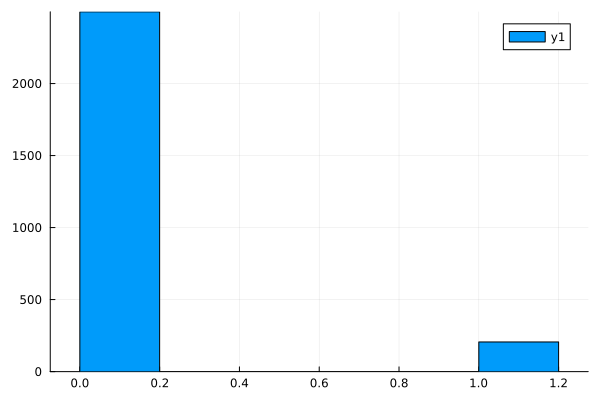

In [291]:
histogram(map(i -> i[1] == 3, rand(cards, 2704)))

In [14]:
1/length(collect(permutations(cards, 2)))

0.0003770739064856712

But after trying 2,704,000 we get even more close to that probability.

In [15]:
length(collect(permutations(cards, 4)))

6497400

### Flipping a coin also illustrates randoness.

We can therefore start with an hello world example in probability with a data.data.Coin flip or by rolling a dice.

**simulating a coind flip and dice role 5 times**

In [53]:
rand(datas.Coin, 5)

5-element Vector{Char}:
 'H': ASCII/Unicode U+0048 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'H': ASCII/Unicode U+0048 (category Lu: Letter, uppercase)

In [45]:
event_occurency('H', rand(datas.Coin, 10))

5

When we calculate the probability of get Heads we get almost 100% after 200 flips.

In [482]:
flips = rand(datas.Coin, 200)

200-element Vector{Char}:
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'H': ASCII/Unicode U+0048 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'H': ASCII/Unicode U+0048 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'H': ASCII/Unicode U+0048 (category Lu: Letter, uppercase)
 'H': ASCII/Unicode U+0048 (category Lu: Letter, uppercase)
 ⋮
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'H': ASCII/Unicode U+0048 (category Lu: Letter, uppercase)
 'T': ASCII/Unicode U+0054 (category Lu: Letter, uppercase)
 'H': ASCII/Unicode U+0048 (category Lu: Letter, uppercase)
 'H': ASCII/Unicode U+0048 (category Lu: Letter, uppercase)
 'H': ASCII

In [519]:
event_of = map(p -> count(f -> f == 'H', p), Iterators.partition(flips, 6))

34-element Vector{Int64}:
 2
 3
 2
 4
 2
 2
 3
 2
 2
 4
 ⋮
 2
 3
 6
 1
 1
 2
 3
 4
 1

In [517]:
prob(event_occurency(6, event_of), 200)

0.005

### The appearance of randoness in $\pi$.

In [409]:
collect(2//n^2 for n in 1:10)

10-element Vector{Rational{Int64}}:
  2
 1//2
 2//9
 1//8
 2//25
 1//18
 2//49
 1//32
 2//81
 1//50

In [561]:
big(π)

3.141592653589793238462643383279502884197169399375105820974944592307816406286198

In [540]:
length(string(big(π)))

80

3.141592653589793238462643383279502884197169399375105820974944592307816406286198

neeed too finish this...

In [564]:
digits(string(big(π)))

MethodError: MethodError: no method matching digits(::String)
The function `digits` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  digits(!Matched::Type{<:Integer}, !Matched::Integer; base, pad)
   @ Base intfuncs.jl:1017
  digits(!Matched::Integer; base, pad)
   @ Base intfuncs.jl:1014


In [563]:
count(p -> p == 3, string(big(π)))

0